In [1]:
import os
import numpy as np
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

In [2]:
train_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_train_base.json'

In [3]:
test_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_test_base.json'

In [4]:
val_data_json_path = \
    '/home/dkeng/2025-promega-mini-test/data_splits/both_val_base.json'

In [5]:
with open(train_data_json_path, 'r') as f:
    train_data_json = json.load(f)
with open(val_data_json_path, 'r') as f:
    val_data_json = json.load(f)
with open(test_data_json_path, 'r') as f:
    test_data_json = json.load(f)

In [6]:
def json_to_df(json):
    rows=[]
    for org_id, info in json.items():
        label = info.get("label")
        batch = info.get("batch")
        timepoints = info.get("timepoints", {})

        for day_name, tp in timepoints.items():
            row = {
            "ID": org_id,          # your organoid id
            "batch": batch,
            "label": label,
            "DY": day_name,        # e.g. "Dy03"
            "img_path": tp.get("img_path"),
            "mask_path": tp.get("mask_path"),
            }

        # add metabolites
            for k, v in tp.get("metabolites", {}).items():
                row[k] = v

            rows.append(row)
    return pd.DataFrame(rows)
    

In [7]:
train_df = json_to_df(train_data_json)
test_df = json_to_df(test_data_json)
val_df = json_to_df(val_data_json)

In [75]:
# IDs only in dy6_train_df
only_in_dy6 = dy6_train_df[~dy6_train_df['ID'].isin(dy28_train_df['ID'])]

# IDs only in dy28_test_df
only_in_dy28 = dy28_train_df[~dy28_train_df['ID'].isin(dy6_train_df['ID'])]

In [88]:
def metabolite_classifier(trainval, test_df, methodstr= "lgbm"):
    output_df = pd.DataFrame(columns=['DY', 'accuracy_score_value','precision_accept', 'precision_notaccept','recall_accept','recall_notaccept','f1-score_accept','f1-score_accept'])
    rows = []
    for days in np.unique(trainval.DY):
        print(days)
        selected_train_df = trainval[trainval['DY']==days]
        selected_test_df = test_df[test_df['DY']==days]
        #print(len(selected_test_df))
    #per_day_metabolite_survey_data = pd.merge(survey_label_selected, selected_meta_df, left_on='ID-DY', right_on='ID-DY', how='inner')
    #per_day_metabolite_survey_data = per_day_metabolite_survey_data[~per_day_metabolite_survey_data['sample_id'].str.contains('BA4', na=False)]
    #print(days+':+'+str(len(selected_meta_df[selected_meta_df['majority_agreed_consensus']=='Acceptable']))+',-'+str(len(per_day_metabolite_survey_data[per_day_metabolite_survey_data['majority_agreed_consensus']!='Acceptable'])))
        day_num= int(re.search(r'\d+', days).group())
        if day_num <= 10:
            train_data=selected_train_df.drop(columns=["DY",'batch','ID','img_path','mask_path','MalateGlo_concentration_uM', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration'])
            test_data=selected_test_df.drop(columns=["DY",'batch','ID','img_path','mask_path','MalateGlo_concentration_uM', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration'])

        else: 
            train_data=selected_train_df.drop(columns=["DY",'batch','ID','img_path','mask_path', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration'])
            test_data=selected_test_df.drop(columns=["DY",'batch','ID','img_path','mask_path', 'MalateGlo_initial_concentration', 'GlucoseGlo_initial_concentration','GlutamateGlo_initial_concentration',
                                      'LactateGlo_initial_concentration', 'PyruvateGlo_initial_concentration'])
     
    # Split features and labels
        X_train = train_data.drop(["label"],axis=1)
        y_train = train_data['label']
        X_test = test_data.drop(["label"],axis=1)
        y_test = test_data['label']

        scaler = StandardScaler()
        
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
            )
            #X_train_scaled = pd.DataFrame(
            #scaler.fit_transform(X_train),
            #columns=X_train.columns,
            #index=X_train.index
            #)
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
            )



        #Random Forest
        if methodstr == 'rf':

        # Train the classifier
            param_grid = {
            "n_estimators": [500, 1000],
            #"max_depth": [None, 5],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
            }
            model = RandomForestClassifier(random_state=42)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            grid = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
            grid.fit(X_train_scaled, y_train)

            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test_scaled)


        #LGBM
        if methodstr == 'lgbm':
        # Train the classifier
            model = LGBMClassifier(random_state=42,verbose=-1)

            param_grid = {
            'max_depth': [4, 6, 8],
            'learning_rate': [0.01, 0.05],
            'n_estimators': [ 200 , 500, 1000]
            }
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            grid = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
            grid.fit(X_train_scaled, y_train)
            best_model = grid.best_estimator_
        #Predict
            y_pred = best_model.predict(X_test_scaled)
            print("Best Params:", grid.best_params_)
            

        if methodstr == 'LogisticRegression_SMOTE':
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)


        # Resample
        
            sm = SMOTE(random_state=42)
            X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)
            print(X_resampled)

        # Train model with class weights
            model = LogisticRegression(class_weight='balanced', solver='liblinear')
            model.fit(X_resampled, y_resampled)

        # Predict and evaluate
            y_pred = model.predict(X_test_scaled)



 
        
        selected_test_df['predictions'] = y_pred
        different_rows = selected_test_df[selected_test_df['label'] != selected_test_df['predictions']]
        print(different_rows["ID"])

        

    # Evaluation
        accuracy_score_value  = accuracy_score(y_test, y_pred)
        print("Accuracy:", accuracy_score_value )
        report = classification_report(y_test, y_pred,output_dict=True)
        print("Classification Report:\n", classification_report(y_test, y_pred) )

        precision_accept = report['Acceptable']['precision'] 
        precision_notaccept = report['Not Acceptable']['precision'] 
        recall_accept = report['Acceptable']['recall'] 
        recall_notaccept = report['Not Acceptable']['recall'] 
        f1_score_accept = report['Acceptable']['f1-score'] 
        f1_score_notaccept = report['Not Acceptable']['f1-score'] 
        rows.append({
        "DY": days,
        "accuracy_score_value": accuracy_score_value,
        "precision_accept": precision_accept,
        "precision_notaccept": precision_notaccept,
        "recall_accept": recall_accept,
        "recall_notaccept": recall_notaccept,
        "f1-score_accept": f1_score_accept,
        "f1-score_notaccept": f1_score_notaccept,
        })


        s = pd.Series([days, accuracy_score_value,precision_accept, precision_notaccept,recall_accept,recall_notaccept, f1_score_accept, f1_score_notaccept],                 
                   index=['DY', 'accuracy_score_value','precision_accept', 'precision_notaccept','recall_accept','recall_notaccept','f1-score_accept','f1-score_notaccept' ])
        output_df = pd.DataFrame(rows, columns=[
        "DY","accuracy_score_value","precision_accept","precision_notaccept",
        "recall_accept","recall_notaccept","f1-score_accept","f1-score_notaccept"])
            

    # Generate confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

    # Plot confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix" + days)
        plt.tight_layout()

Dy03
37
Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500}
117     BA2 96_2 B6
149     BA1 96_1 G3
227     BA2 96_2 G4
238     BA2 96_1 B3
271    BA2 96_1 A12
350     BA2 96_1 B8
383     BA1 96_1 C7
393     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.7837837837837838
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.94      0.88        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.78        37
     macro avg       0.41      0.47      0.44        37
  weighted avg       0.69      0.78      0.74        37

Dy06
37


/tmp/ipykernel_132685/3747381882.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 1000}
163     BA2 96_2 B1
228     BA2 96_2 G4
239     BA2 96_1 B3
272    BA2 96_1 A12
351     BA2 96_1 B8
384     BA1 96_1 C7
394     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.97      0.90        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.81        37
     macro avg       0.42      0.48      0.45        37
  weighted avg       0.70      0.81      0.75        37

Dy08
37


/tmp/ipykernel_132685/3747381882.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}
2       BA2 96_1 G6
48      BA1 96_1 H7
229     BA2 96_2 G4
240     BA2 96_1 B3
273    BA2 96_1 A12
294     BA2 96_2 E6
329     BA1 96_1 F8
352     BA2 96_1 B8
385     BA1 96_1 C7
395     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.7297297297297297
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.82      0.87      0.84        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.73        37
     macro avg       0.41      0.44      0.42        37
  weighted avg       0.69      0.73      0.71        37

Dy10
37


...

/tmp/ipykernel_132685/3747381882.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
280    BA2 96_1 A12
312    BA2 96_1 F10
391     BA1 96_1 C7
402     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.9090909090909091
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.97      0.94        35
Not Acceptable       0.86      0.67      0.75         9

      accuracy                           0.91        44
     macro avg       0.89      0.82      0.85        44
  weighted avg       0.91      0.91      0.90        44

Dy30
44


/tmp/ipykernel_132685/3747381882.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
281    BA2 96_1 A12
313    BA2 96_1 F10
392     BA1 96_1 C7
403     BA2 96_1 E9
Name: ID, dtype: object
Accuracy: 0.9090909090909091
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.97      0.94        35
Not Acceptable       0.86      0.67      0.75         9

      accuracy                           0.91        44
     macro avg       0.89      0.82      0.85        44
  weighted avg       0.91      0.91      0.90        44



/tmp/ipykernel_132685/3747381882.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_df['predictions'] = y_pred


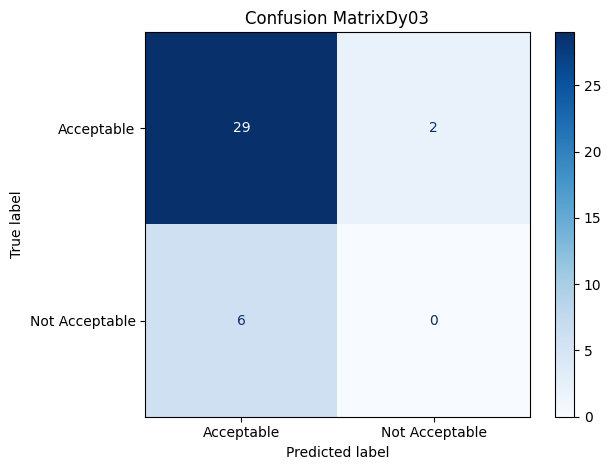

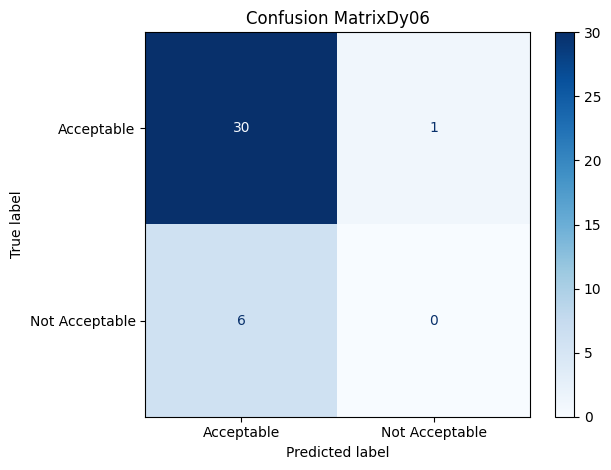

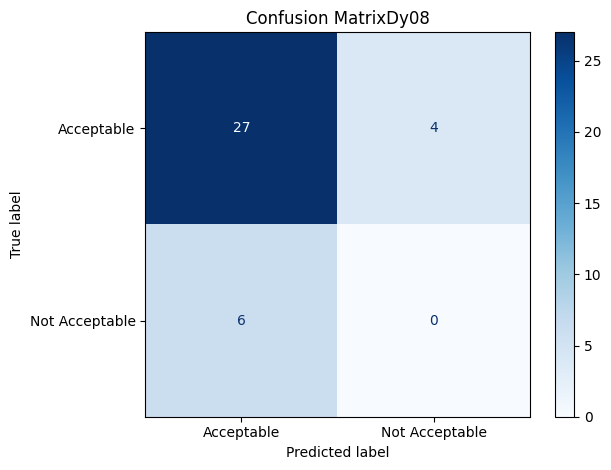

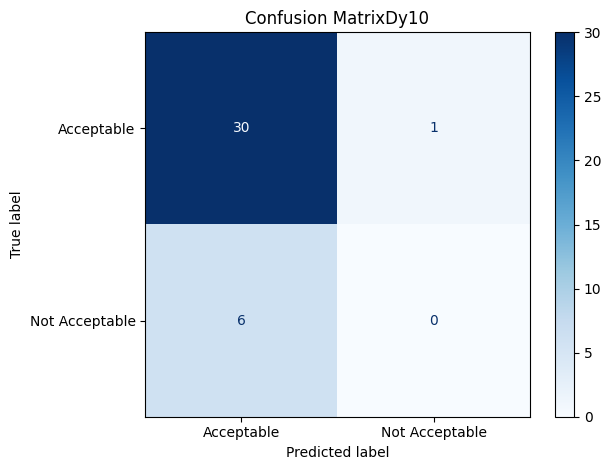

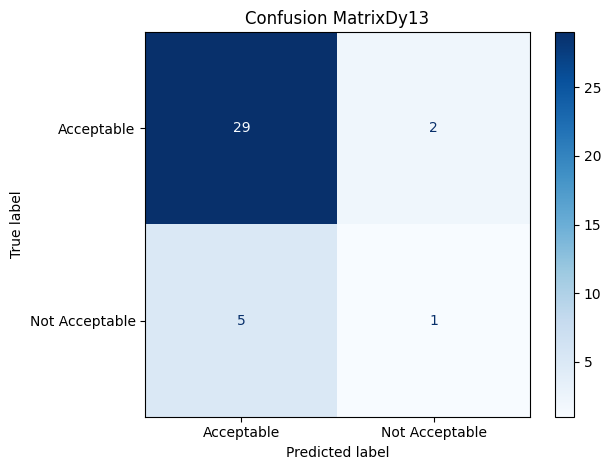

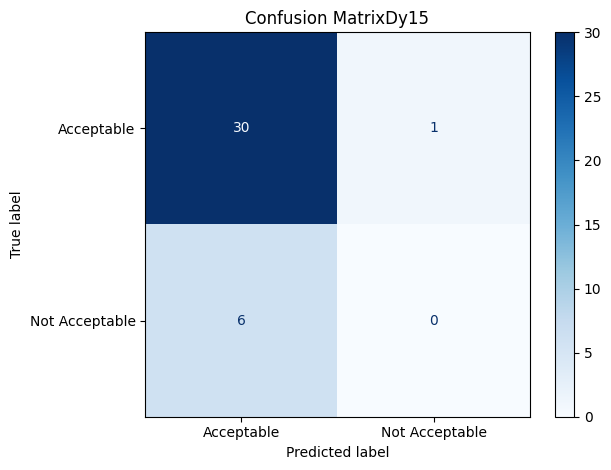

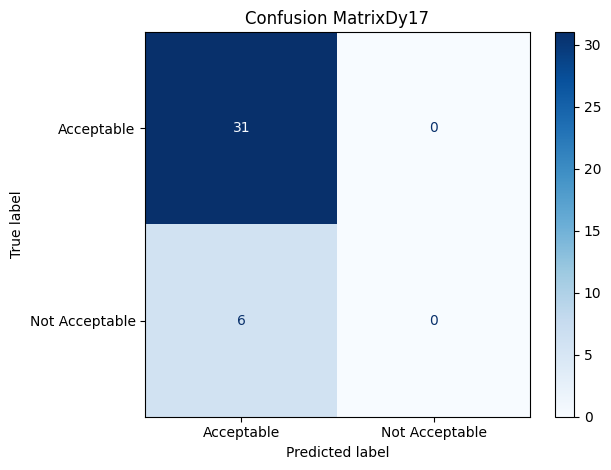

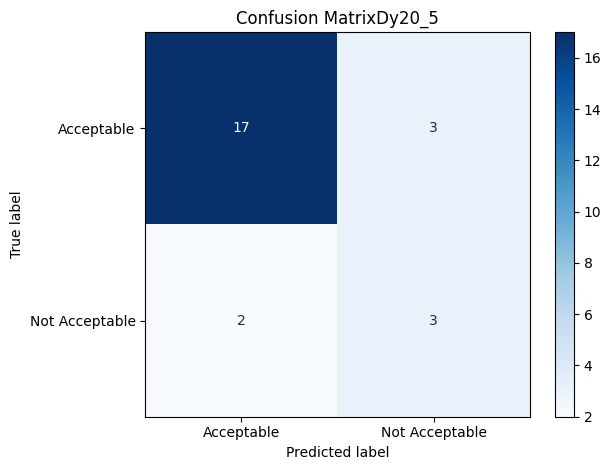

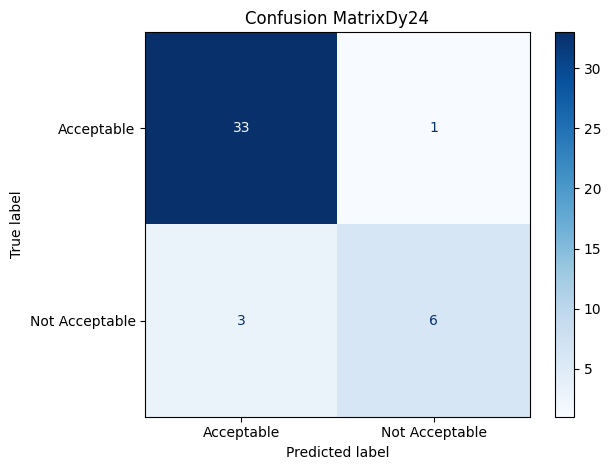

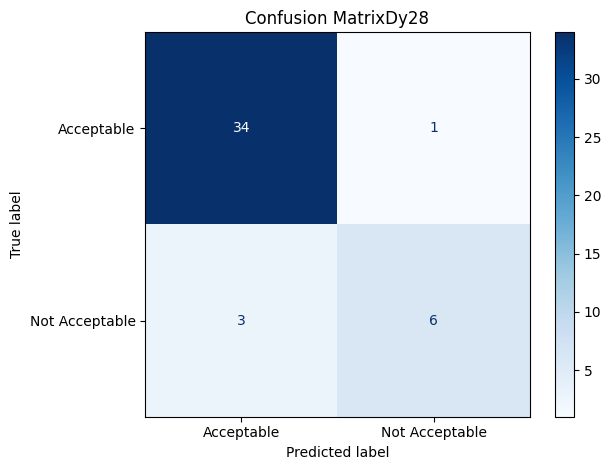

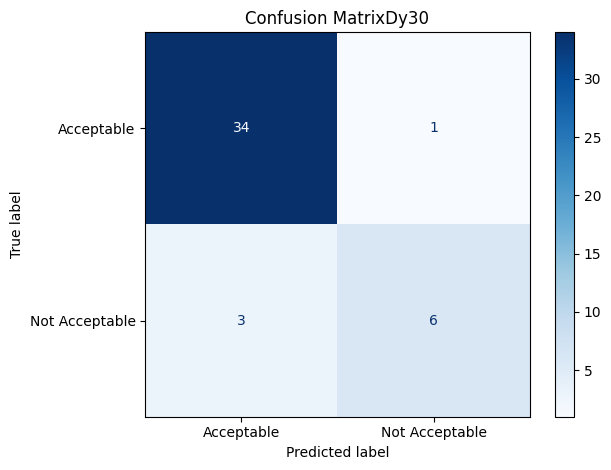

In [89]:
metabolite_classifier(trainval, test_df, methodstr= "lgbm")

Dy03
37
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.86      0.97      0.91        31
Not Acceptable       0.50      0.17      0.25         6

      accuracy                           0.84        37
     macro avg       0.68      0.57      0.58        37
  weighted avg       0.80      0.84      0.80        37

Dy06
37
Accuracy: 0.8378378378378378
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.84      1.00      0.91        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.84        37
     macro avg       0.42      0.50      0.46        37
  weighted avg       0.70      0.84      0.76        37

Dy08
37


/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Accuracy: 0.7837837837837838
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.94      0.88        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.78        37
     macro avg       0.41      0.47      0.44        37
  weighted avg       0.69      0.78      0.74        37

Dy10
37
Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.97      0.90        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.81        37
     macro avg       0.42      0.48      0.45        37
  weighted avg       0.70      0.81      0.75        37

Dy13
37
Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.85      0.94      0.89        31
Not Acceptable       0.33      0.1

/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Accuracy: 0.8108108108108109
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.83      0.97      0.90        31
Not Acceptable       0.00      0.00      0.00         6

      accuracy                           0.81        37
     macro avg       0.42      0.48      0.45        37
  weighted avg       0.70      0.81      0.75        37

Dy20_5
25


/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/home/dkeng/.conda/envs/core_env/lib/python3.11/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Accuracy: 0.84
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.90      0.90      0.90        20
Not Acceptable       0.60      0.60      0.60         5

      accuracy                           0.84        25
     macro avg       0.75      0.75      0.75        25
  weighted avg       0.84      0.84      0.84        25

Dy24
43
Accuracy: 0.9069767441860465
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.97      0.94        34
Not Acceptable       0.86      0.67      0.75         9

      accuracy                           0.91        43
     macro avg       0.89      0.82      0.85        43
  weighted avg       0.90      0.91      0.90        43

Dy28
44
Accuracy: 0.9090909090909091
Classification Report:
                 precision    recall  f1-score   support

    Acceptable       0.92      0.97      0.94        35
Not Acceptable       0.86      0.67      0.75   

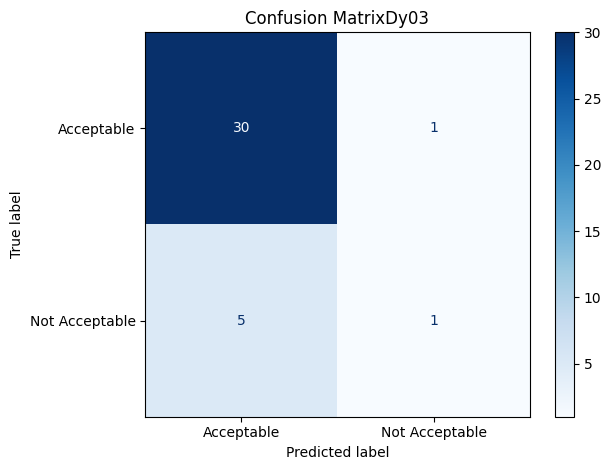

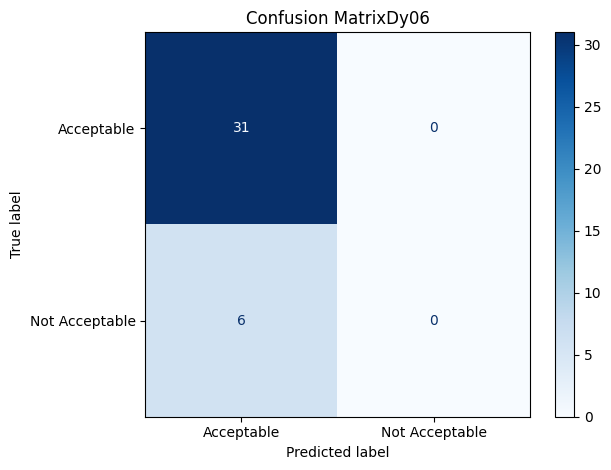

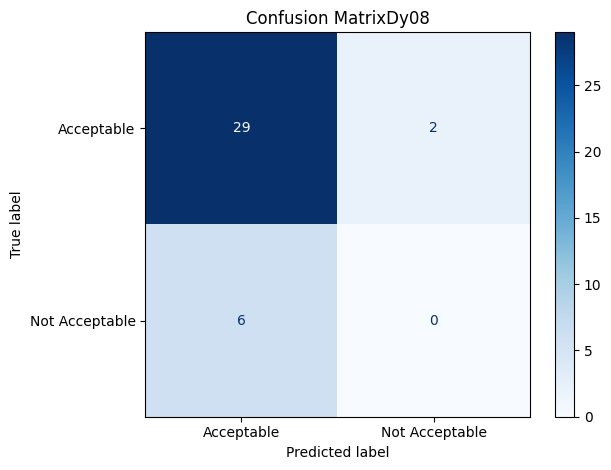

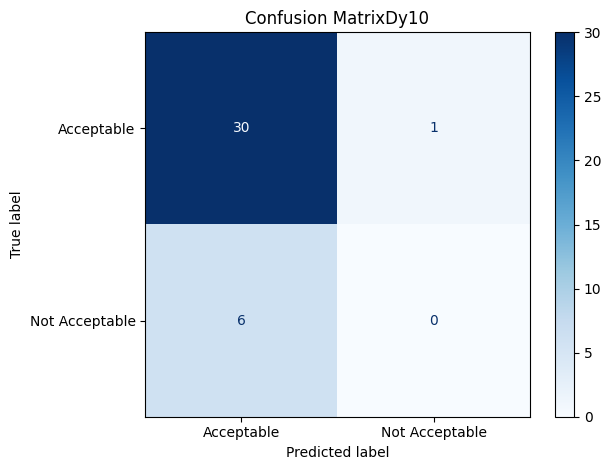

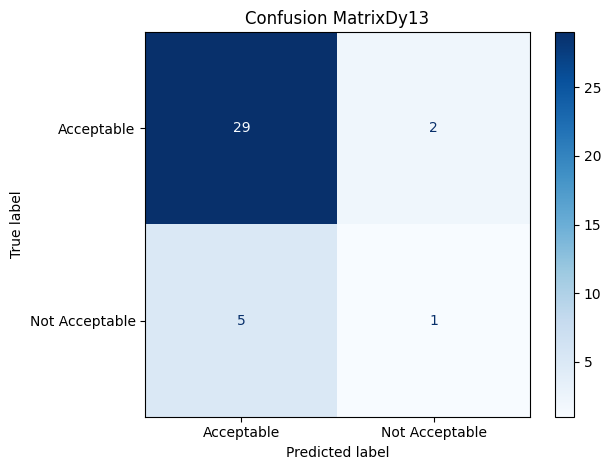

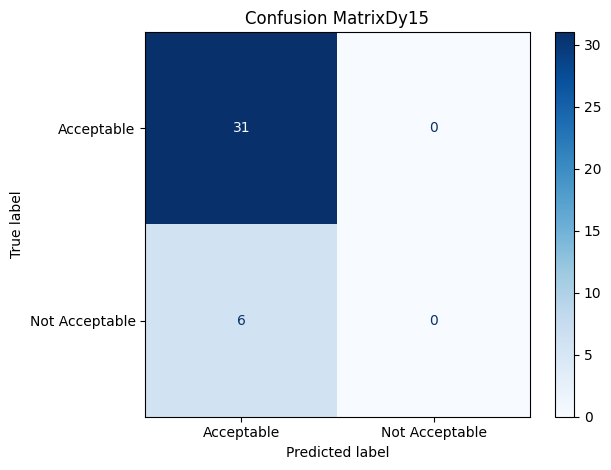

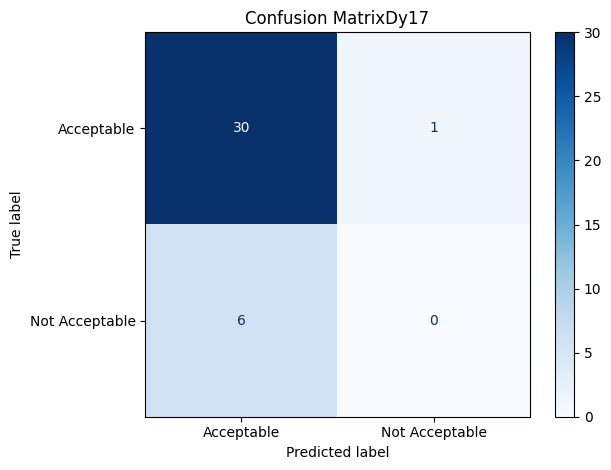

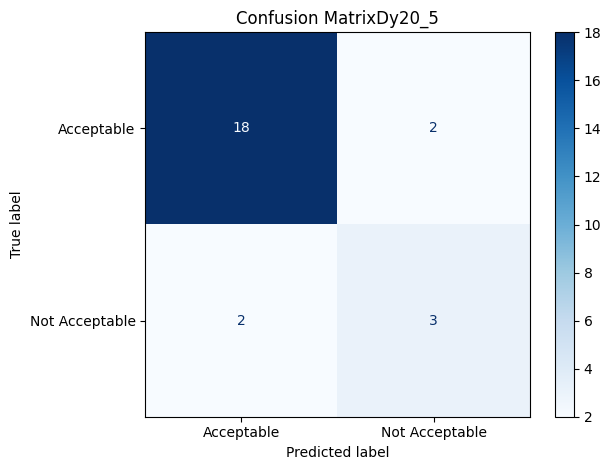

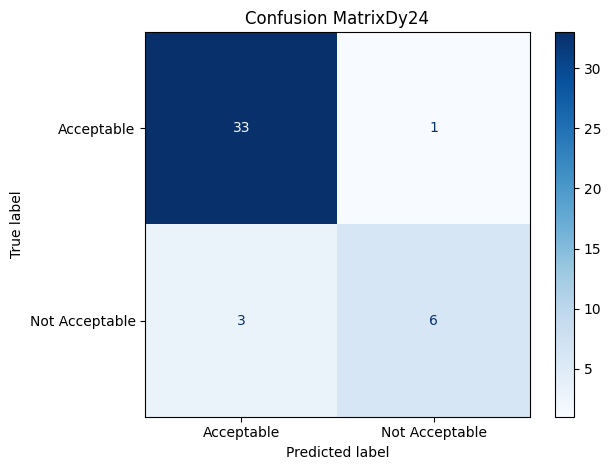

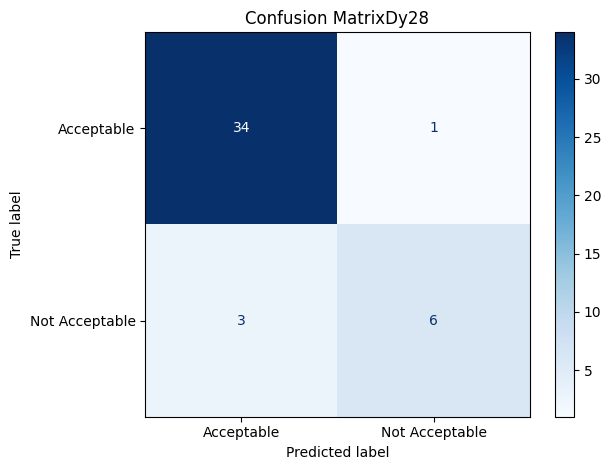

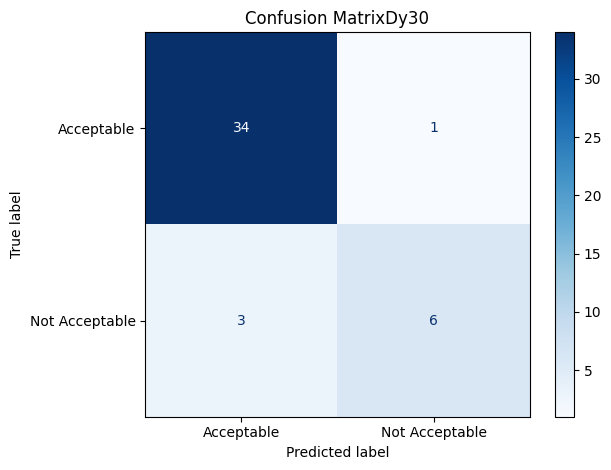

In [83]:
metabolite_classifier(trainval, test_df, methodstr= "rf")